# Domain Link Graph Analysis

Weighted link counts between domains extracted from Common Crawl CC-MAIN-2024-38.

Source: `count_domain_links.py` job on AWS EMR Serverless — fetched WARC records, parsed HTML `<a href>` links, and classified each link into one of four buckets based on its HTML context:

- **nav_count** — inside `<header>`, `<footer>`, `<nav>`, `<aside>`, or nav/menu/banner class hints → site-wide structural links
- **body_count** — inside `<article>`, `<main>`, `<p>`, or content/story/prose class hints → editorial citations
- **related_count** — related-article widgets, recommendation carousels
- **other_count** — sidebars, bylines, share buttons, uncontextualized links

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob

files = glob.glob('results/domain_links/part-*.parquet')
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

# Total link count across all categories
df['total_count'] = df['nav_count'] + df['body_count'] + df['related_count'] + df['other_count']

print(f"Loaded {len(df):,} rows from {len(files)} parquet files")

Loaded 21,183 rows from 5 parquet files


## Overview

In [2]:
total_links = df['total_count'].sum()

print(f"Unique (source, target) pairs: {len(df):,}")
print(f"Unique source domains:          {df['s'].nunique():,}")
print(f"Unique target domains:          {df['t'].nunique():,}")
print(f"Total link occurrences:         {total_links:,}")
print()
print("Link volume by category:")
for col in ['nav_count', 'body_count', 'related_count', 'other_count']:
    vol = df[col].sum()
    print(f"  {col:<15} {vol:>12,}  ({vol/total_links*100:.1f}%)")
print()
print("total_count distribution:")
print(df['total_count'].describe().apply(lambda x: f"{x:,.1f}"))

Unique (source, target) pairs: 21,183
Unique source domains:          372
Unique target domains:          1,035
Total link occurrences:         3,968,662

Link volume by category:
  nav_count          3,586,660  (90.4%)
  body_count           365,924  (9.2%)
  related_count            813  (0.0%)
  other_count           15,265  (0.4%)

total_count distribution:
count     21,183.0
mean         187.4
std        4,182.2
min            1.0
25%            1.0
50%            2.0
75%            4.0
max      257,473.0
Name: total_count, dtype: str


## Link Count Distribution

Both `nav_count` and `body_count` are right-skewed, but for different reasons:
- **nav_count** is dominated by site-wide footer/nav bars repeated across thousands of pages — a handful of (s, t) pairs accumulate enormous counts
- **body_count** is more evenly distributed — editorial citations are rarer and page-specific

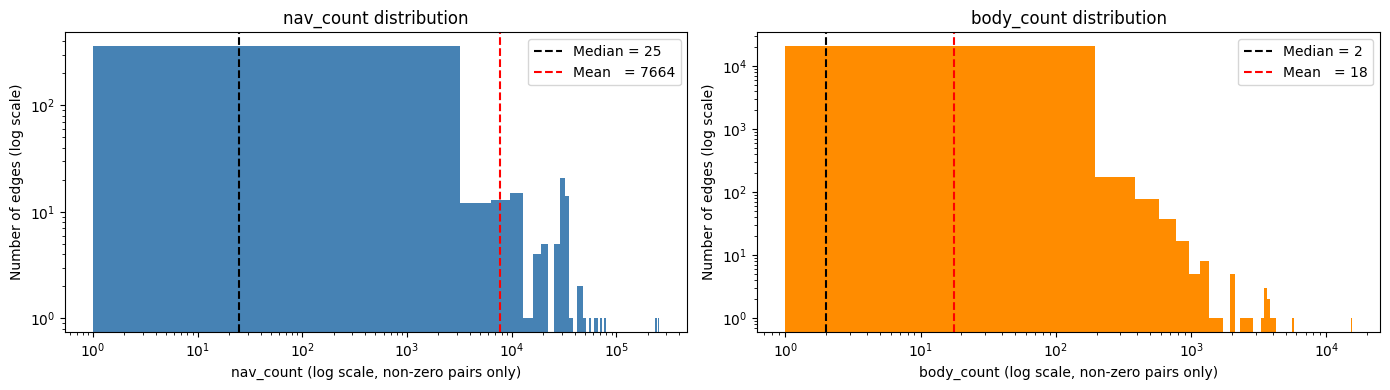

nav_count: top 1% of edges (211) account for 99.9% of total volume
body_count: top 1% of edges (211) account for 49.1% of total volume


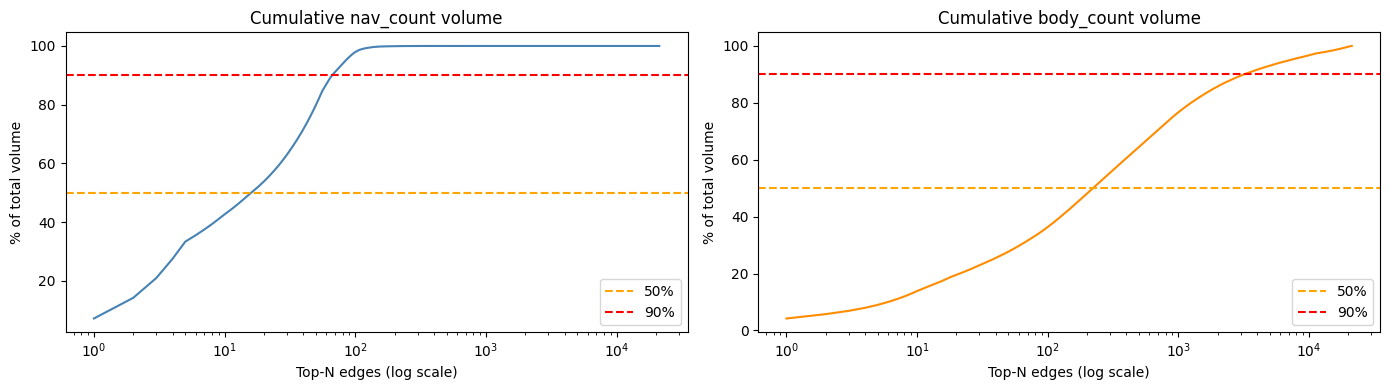

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color in [
    (axes[0], 'nav_count',  'steelblue'),
    (axes[1], 'body_count', 'darkorange'),
]:
    data = df[col]
    nonzero = data[data > 0]
    ax.hist(nonzero, bins=80, color=color, edgecolor='none')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.axvline(nonzero.median(), color='black',  linestyle='--',
               label=f"Median = {nonzero.median():.0f}")
    ax.axvline(nonzero.mean(),   color='red',    linestyle='--',
               label=f"Mean   = {nonzero.mean():.0f}")
    ax.set_xlabel(f'{col} (log scale, non-zero pairs only)')
    ax.set_ylabel('Number of edges (log scale)')
    ax.set_title(f'{col} distribution')
    ax.legend()

plt.tight_layout()
plt.show()

# Cumulative volume: nav vs body
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in [
    (axes[0], 'nav_count',  'steelblue'),
    (axes[1], 'body_count', 'darkorange'),
]:
    sorted_vals = df[col].sort_values(ascending=False).values
    total = sorted_vals.sum()
    if total == 0:
        continue
    cumulative = np.cumsum(sorted_vals) / total * 100
    ax.plot(range(1, len(cumulative) + 1), cumulative, color=color)
    ax.set_xscale('log')
    ax.set_xlabel('Top-N edges (log scale)')
    ax.set_ylabel('% of total volume')
    ax.set_title(f'Cumulative {col} volume')
    for pct, lc in [(50, 'orange'), (90, 'red')]:
        ax.axhline(pct, color=lc, linestyle='--', label=f'{pct}%')
    ax.legend()

    top1pct = max(1, int(len(df) * 0.01))
    vol_top = sorted_vals[:top1pct].sum() / total * 100
    print(f"{col}: top 1% of edges ({top1pct:,}) account for {vol_top:.1f}% of total volume")

plt.tight_layout()
plt.show()

## Top Domains

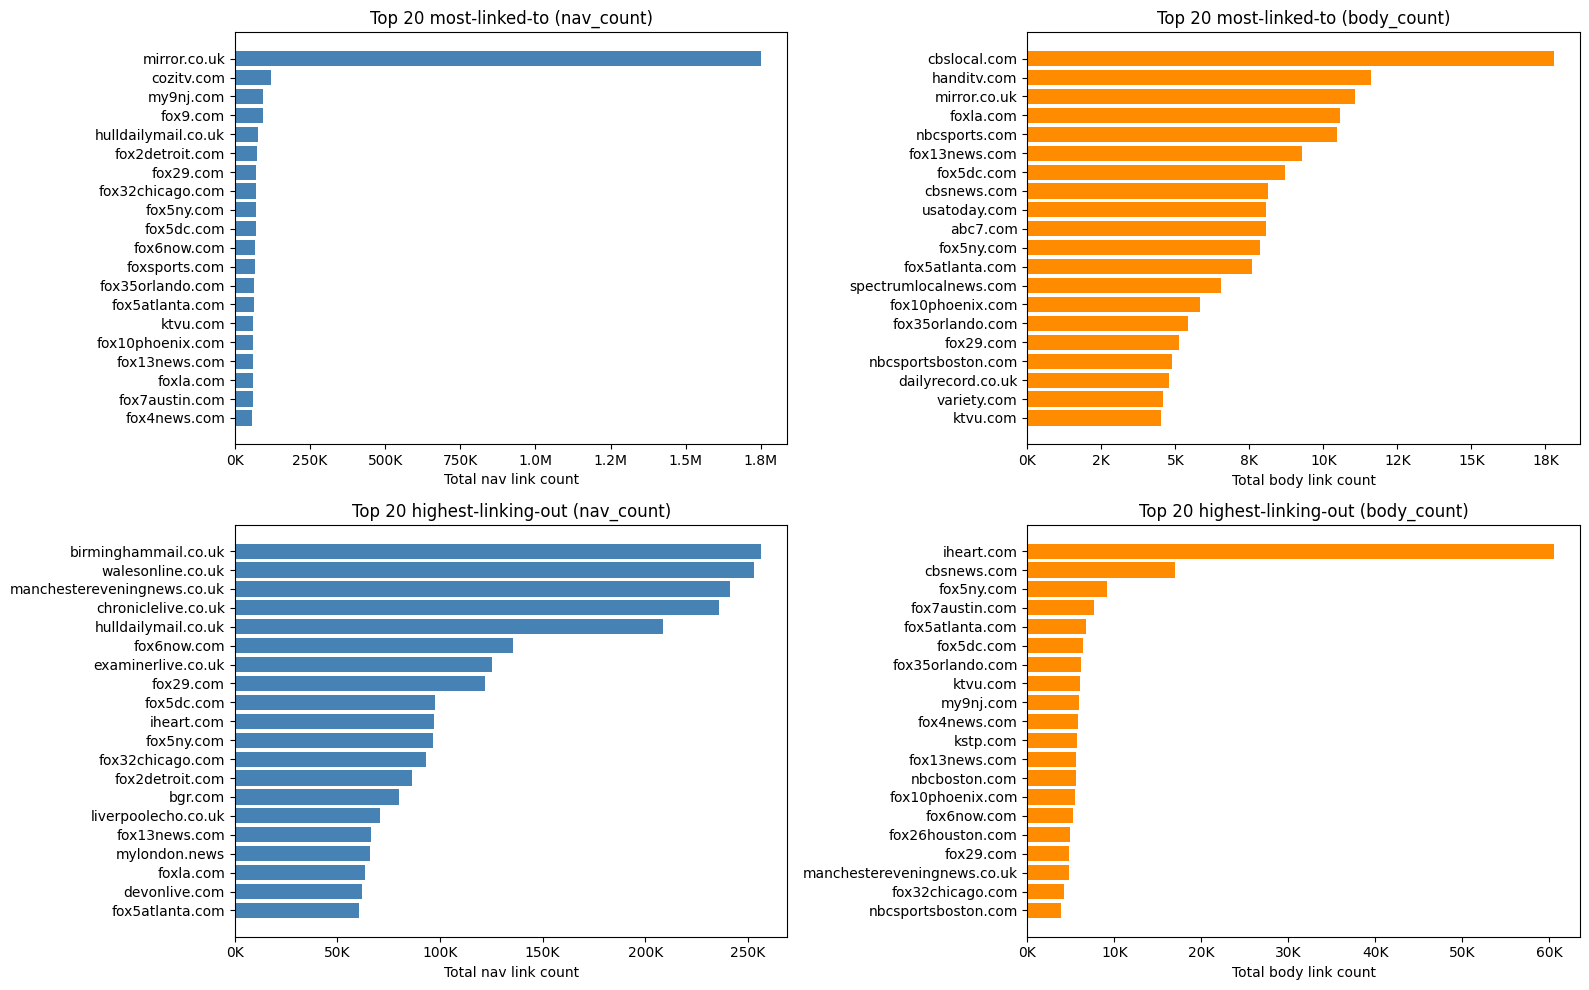

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, direction, group_col, title_suffix in [
    (0, 'incoming', 't', 'most-linked-to'),
    (1, 'outgoing', 's', 'highest-linking-out'),
]:
    for col_idx, (count_col, color, label) in enumerate([
        ('nav_count',  'steelblue',   'nav'),
        ('body_count', 'darkorange',  'body'),
    ]):
        ax = axes[row][col_idx]
        top = df.groupby(group_col)[count_col].sum().sort_values(ascending=False).head(20)
        ax.barh(top.index[::-1], top.values[::-1], color=color)
        ax.set_title(f'Top 20 {title_suffix} ({label}_count)')
        ax.set_xlabel(f'Total {label} link count')
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

## Nav vs Body Breakdown per Edge

With the 4-bucket classifier we can directly inspect the nav/body split for each (s, t) pair — no threshold heuristic needed.

- Pairs with high `nav_count` and low `body_count` → site-wide footer/nav links (repeated on every page)
- Pairs with high `body_count` relative to `nav_count` → genuine editorial citations

We define a **body ratio** = `body_count / total_count` per edge as a clean signal for editorial intent.

Nav-dominated edges  (body_ratio < 0.1):  409 pairs  (1.9%)  |  90.1% of total link volume
Body-dominated edges (body_ratio >= 0.5): 20,734 pairs  (97.9%)  |  8.3% of total link volume



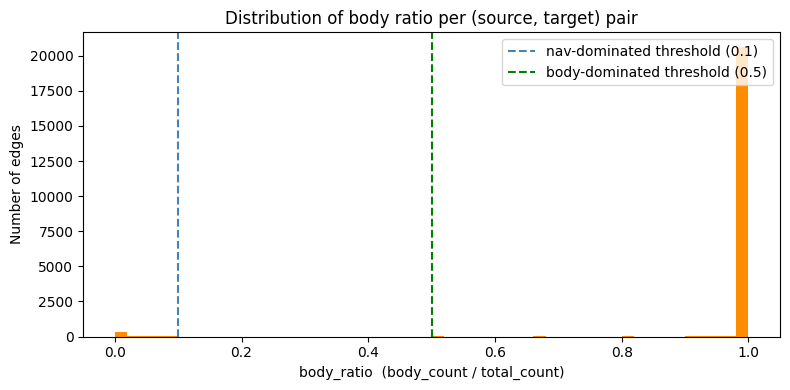

Top nav-dominated edges (lowest body_ratio, highest total_count):
                          s                   t  nav_count  body_count  total_count  body_ratio
       birminghammail.co.uk        mirror.co.uk     256409        1001       257473    0.003888
          walesonline.co.uk        mirror.co.uk     252828         807       253687    0.003181
manchestereveningnews.co.uk        mirror.co.uk     241433         574       242225    0.002370
        chroniclelive.co.uk        mirror.co.uk     235736         552       236333    0.002336
        hulldailymail.co.uk        mirror.co.uk     208709         742       209454    0.003543
         examinerlive.co.uk hulldailymail.co.uk      78049         122        78175    0.001561
        liverpoolecho.co.uk        mirror.co.uk      70808         865        71673    0.012069
              mylondon.news        mirror.co.uk      65897         158        66084    0.002391
              devonlive.com        mirror.co.uk      62087         791

In [5]:
df['body_ratio'] = df['body_count'] / df['total_count'].replace(0, np.nan)

# Edges dominated by nav (body_ratio < 0.1) vs editorial (body_ratio >= 0.5)
nav_dominated  = df[df['body_ratio'] <  0.1]
body_dominated = df[df['body_ratio'] >= 0.5]

nav_vol  = nav_dominated['total_count'].sum()
body_vol = body_dominated['total_count'].sum()

print(f"Nav-dominated edges  (body_ratio < 0.1):  {len(nav_dominated):,} pairs  "
      f"({len(nav_dominated)/len(df)*100:.1f}%)  |  {nav_vol/total_links*100:.1f}% of total link volume")
print(f"Body-dominated edges (body_ratio >= 0.5): {len(body_dominated):,} pairs  "
      f"({len(body_dominated)/len(df)*100:.1f}%)  |  {body_vol/total_links*100:.1f}% of total link volume")
print()

# Distribution of body_ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['body_ratio'].dropna(), bins=50, color='darkorange', edgecolor='none')
ax.set_xlabel('body_ratio  (body_count / total_count)')
ax.set_ylabel('Number of edges')
ax.set_title('Distribution of body ratio per (source, target) pair')
ax.axvline(0.1, color='steelblue', linestyle='--', label='nav-dominated threshold (0.1)')
ax.axvline(0.5, color='green',     linestyle='--', label='body-dominated threshold (0.5)')
ax.legend()
plt.tight_layout()
plt.show()

print("Top nav-dominated edges (lowest body_ratio, highest total_count):")
print(nav_dominated.nlargest(10, 'total_count')[
    ['s', 't', 'nav_count', 'body_count', 'total_count', 'body_ratio']
].to_string(index=False))
print()
print("Top body-dominated edges (body_ratio >= 0.5, highest body_count):")
print(body_dominated.nlargest(10, 'body_count')[
    ['s', 't', 'nav_count', 'body_count', 'total_count', 'body_ratio']
].to_string(index=False))

## Network Groups: Reach PLC and Fox

Two network effects dominate the high-count edges.

In [6]:
# Reach PLC titles: UK regional papers owned by Reach PLC that cross-link heavily via site-wide nav
reach_titles = [
    'mirror.co.uk', 'birminghammail.co.uk', 'walesonline.co.uk',
    'manchestereveningnews.co.uk', 'chroniclelive.co.uk', 'hulldailymail.co.uk',
    'examinerlive.co.uk', 'liverpoolecho.co.uk', 'mylondon.news', 'devonlive.com',
    'cheshire-live.co.uk', 'nottinghampost.com', 'getsurrey.co.uk',
    'leicestermercury.co.uk', 'stokesentinel.co.uk', 'dailyrecord.co.uk',
    'dailystar.co.uk',
]

# Fox network affiliates
fox_titles = [d for d in df['s'].unique() if 'fox' in d or d in ('cozitv.com', 'my9nj.com')]

reach_internal = df[df['s'].isin(reach_titles) & df['t'].isin(reach_titles)]
fox_internal   = df[df['s'].isin(fox_titles)   & df['t'].isin(fox_titles)]

for label, subset in [('Reach PLC', reach_internal), ('Fox network', fox_internal)]:
    nav_vol  = subset['nav_count'].sum()
    body_vol = subset['body_count'].sum()
    total    = subset['total_count'].sum()
    print(f"=== {label} internal links ===")
    print(f"  Edges: {len(subset):,}  |  Total link volume: {total:,}")
    print(f"  nav_count:   {nav_vol:,}  ({nav_vol/total*100:.1f}%)")
    print(f"  body_count:  {body_vol:,}  ({body_vol/total*100:.1f}%)")
    print(subset.nlargest(8, 'total_count')[
        ['s', 't', 'nav_count', 'body_count', 'total_count']
    ].to_string(index=False))
    print()

=== Reach PLC internal links ===
  Edges: 260  |  Total link volume: 1,857,289
  nav_count:   1,830,590  (98.6%)
  body_count:  26,280  (1.4%)
                          s                   t  nav_count  body_count  total_count
       birminghammail.co.uk        mirror.co.uk     256409        1001       257473
          walesonline.co.uk        mirror.co.uk     252828         807       253687
manchestereveningnews.co.uk        mirror.co.uk     241433         574       242225
        chroniclelive.co.uk        mirror.co.uk     235736         552       236333
        hulldailymail.co.uk        mirror.co.uk     208709         742       209454
         examinerlive.co.uk hulldailymail.co.uk      78049         122        78175
        liverpoolecho.co.uk        mirror.co.uk      70808         865        71673
              mylondon.news        mirror.co.uk      65897         158        66084

=== Fox network internal links ===
  Edges: 325  |  Total link volume: 1,179,312
  nav_count:   1,10

## Editorial Graph: Top Targets and Sources by body_count

`body_count` directly captures editorial citations — links inside article prose — without needing a threshold heuristic. These are the domains most frequently cited in article content.

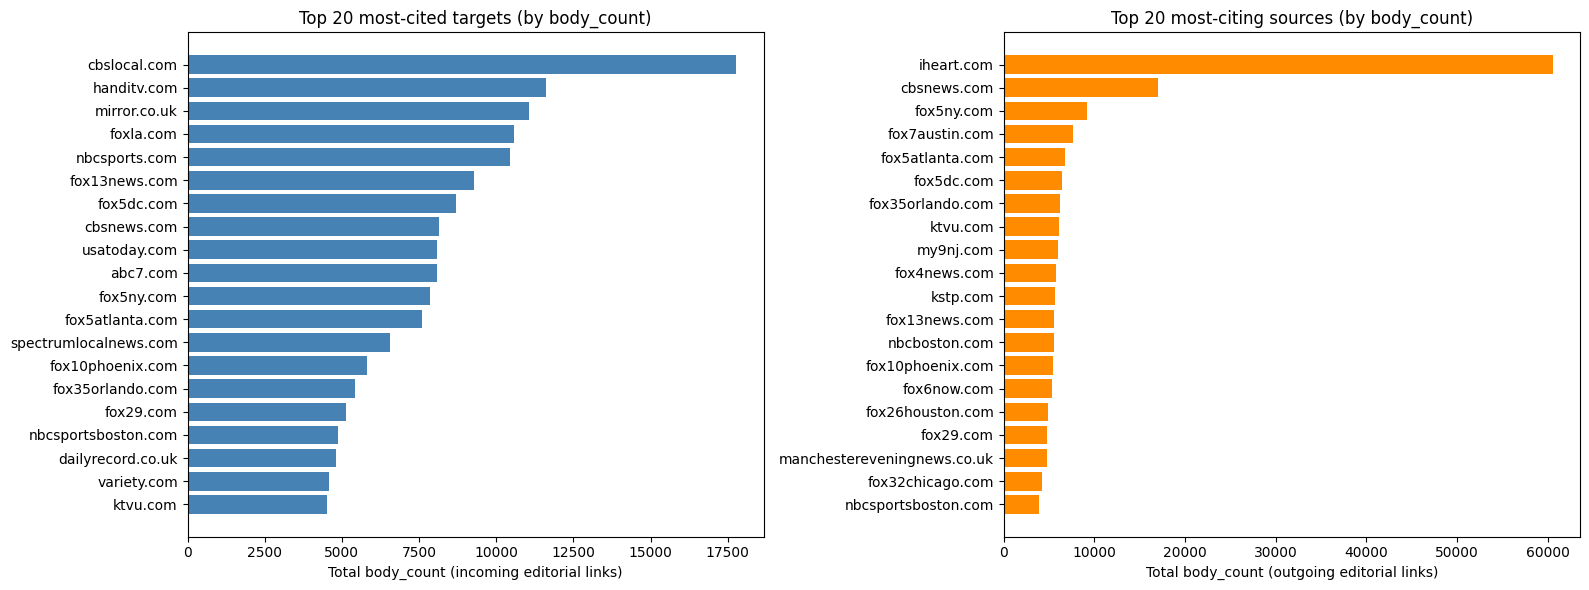

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ed_in  = df.groupby('t')['body_count'].sum().sort_values(ascending=False).head(20)
ed_out = df.groupby('s')['body_count'].sum().sort_values(ascending=False).head(20)

axes[0].barh(ed_in.index[::-1], ed_in.values[::-1], color='steelblue')
axes[0].set_title('Top 20 most-cited targets (by body_count)')
axes[0].set_xlabel('Total body_count (incoming editorial links)')

axes[1].barh(ed_out.index[::-1], ed_out.values[::-1], color='darkorange')
axes[1].set_title('Top 20 most-citing sources (by body_count)')
axes[1].set_xlabel('Total body_count (outgoing editorial links)')

plt.tight_layout()
plt.show()

## Edge Weights for Graph Analysis

For downstream graph algorithms, raw counts need normalisation. Two options:

- **`body_count` directly** — use the editorial signal as the edge weight; ignores nav noise entirely
- **`log1p(body_count)`** — compresses the range for algorithms sensitive to scale
- **`body_ratio`** — fraction of links that are editorial; useful as a link-quality signal independent of page volume

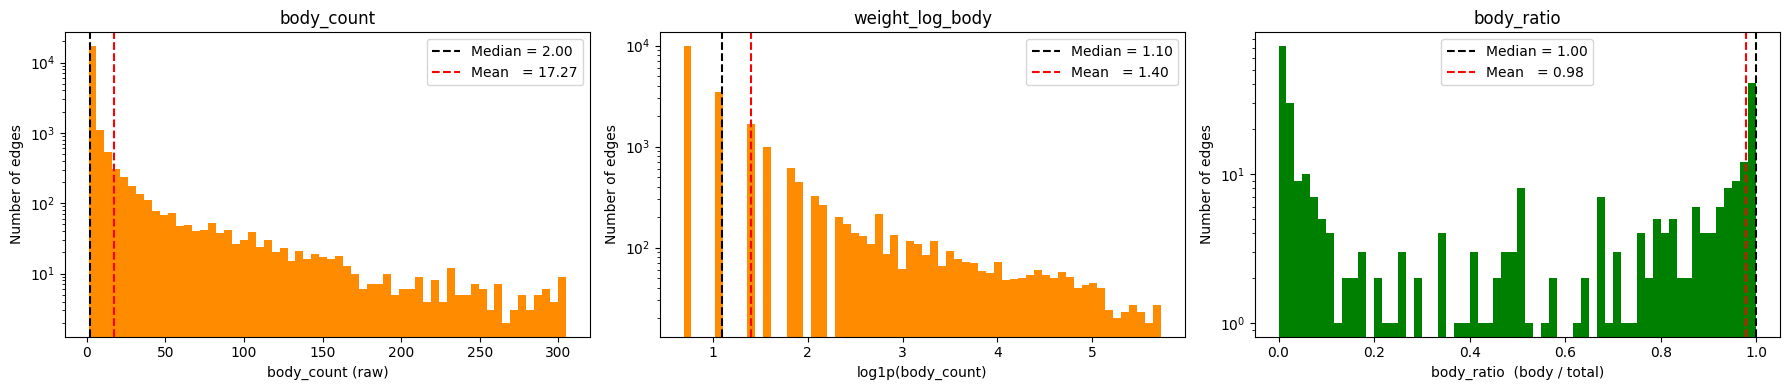

In [11]:
df['weight_log_body'] = np.log1p(df['body_count'])


fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col, color, xlabel in [
    (axes[0], 'body_count',      'darkorange', 'body_count (raw)'),
    (axes[1], 'weight_log_body', 'darkorange', 'log1p(body_count)'),
    (axes[2], 'body_ratio',      'green',      'body_ratio  (body / total)'),
]:
    data = df[col].dropna()
    ax.hist(data[(data > 0) & (data < data.quantile(0.99))], bins=60, color=color, edgecolor='none')
    ax.axvline(data.median(), color='black', linestyle='--',
               label=f"Median = {data.median():.2f}")
    ax.axvline(data.mean(),   color='red',   linestyle='--',
               label=f"Mean   = {data.mean():.2f}")
    ax.set_xlabel(xlabel)
    ax.set_yscale('log')
    ax.set_ylabel('Number of edges')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 454/454 [00:00<00:00, 1157.44it/s]


2.069400498139979 78.0


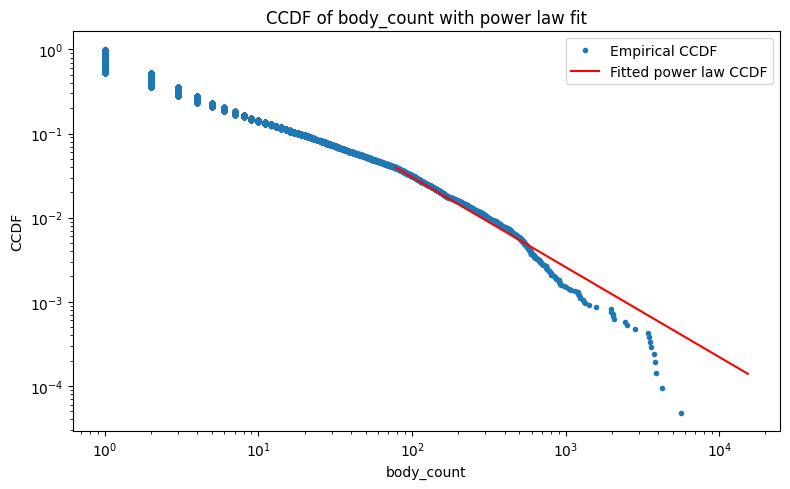

In [26]:
import powerlaw

fig, ax = plt.subplots(figsize=(8,5))

body_counts = df['body_count']
body_counts_nonzero = body_counts[body_counts > 0]
fit = powerlaw.Fit(body_counts_nonzero)
print(fit.alpha, fit.xmin)


sorted_counts = np.sort(body_counts_nonzero)
n = len(sorted_counts)
ccdf = 1 - np.arange(1, n + 1) / n

ax.plot(sorted_counts, ccdf, '.', label="Empirical CCDF")

# Anchor the fit to the empirical CCDF value at xmin
xmin_idx = np.searchsorted(sorted_counts, fit.xmin, side='left')
scale = ccdf[xmin_idx]  # empirical CCDF at xmin

x = np.linspace(fit.xmin, sorted_counts.max(), 200)
ccdf_fit = scale * (x / fit.xmin) ** (1 - fit.alpha)

ax.plot(x, ccdf_fit, color="red", label="Fitted power law CCDF")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("body_count")
ax.set_ylabel("CCDF")
ax.set_title("CCDF of body_count with power law fit")
ax.legend()

plt.tight_layout()
plt.show()

In [12]:
total_pairs    = len(df)
unique_sources = df['s'].nunique()
unique_targets = df['t'].nunique()

nav_vol     = df['nav_count'].sum()
body_vol    = df['body_count'].sum()
related_vol = df['related_count'].sum()
other_vol   = df['other_count'].sum()

nav_dom_pct  = len(nav_dominated)  / total_pairs * 100
body_dom_pct = len(body_dominated) / total_pairs * 100

print("Summary")
print("=" * 55)
print(f"(source, target) pairs        {total_pairs:>10,}")
print(f"Unique sources                {unique_sources:>10,}")
print(f"Unique targets                {unique_targets:>10,}")
print(f"Total link occurrences        {total_links:>10,}")
print()
print("Link volume by category:")
print(f"  nav_count      {nav_vol:>12,}  ({nav_vol/total_links*100:.1f}%)")
print(f"  body_count     {body_vol:>12,}  ({body_vol/total_links*100:.1f}%)")
print(f"  related_count  {related_vol:>12,}  ({related_vol/total_links*100:.1f}%)")
print(f"  other_count    {other_vol:>12,}  ({other_vol/total_links*100:.1f}%)")
print()
print("Edge breakdown by body_ratio:")
print(f"  Nav-dominated  (body_ratio < 0.1)   {len(nav_dominated):>6,} pairs  ({nav_dom_pct:.1f}%)")
print(f"  Body-dominated (body_ratio >= 0.5)  {len(body_dominated):>6,} pairs  ({body_dom_pct:.1f}%)")
print()
print("body_count distribution (non-zero pairs):")
nonzero_body = df[df['body_count'] > 0]['body_count']
print(f"  median  {nonzero_body.median():.0f}")
print(f"  mean    {nonzero_body.mean():.1f}")
print(f"  max     {nonzero_body.max():,}")

Summary
(source, target) pairs            21,183
Unique sources                       372
Unique targets                     1,035
Total link occurrences         3,968,662

Link volume by category:
  nav_count         3,586,660  (90.4%)
  body_count          365,924  (9.2%)
  related_count           813  (0.0%)
  other_count          15,265  (0.4%)

Edge breakdown by body_ratio:
  Nav-dominated  (body_ratio < 0.1)      409 pairs  (1.9%)
  Body-dominated (body_ratio >= 0.5)  20,734 pairs  (97.9%)

body_count distribution (non-zero pairs):
  median  2
  mean    17.5
  max     15,364
